# Classification from Scratch v3 (NumPy only) — Response, 3/3-only ablation

**Version:** 3rd Version (feature ablation). **Role:** primary deliverable. Pure-NumPy twin of `classification_pytorch_v3.ipynb`.

**What changed vs v2:** features only — 3/3 consensus (10 cols, all numeric → 10 dims, one-hot block deleted). Same ResNet arch (in_dim=10), same Adam+cosine+wd, 100 epochs, same splits/seed. Weights → `./weights_v3/classification_scratch.npz`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

SEED = 42
np.random.seed(SEED)
os.makedirs("weights_v3", exist_ok=True)

# ---- 1. LOAD DATA (3/3 features only) ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
print("cleaned:", df.shape, "| Response rate:", round(df["Response"].mean(), 4))

CLF_3OF3 = [
    "AcceptedCmp5", "AcceptedCmp3", "MntWines", "MntMeatProducts",
    "NumCatalogPurchases", "Recency", "Customer_Tenure_Days", "MntGoldProds",
    "Income", "MntFruits",
]
X_full = df[CLF_3OF3].copy()
FEATURE_COLS = list(X_full.columns)
y_full = df["Response"].astype(float).values
print(f"features: {len(FEATURE_COLS)} dims, all numeric (no one-hot needed)")

cleaned: (2237, 28) | Response rate: 0.1493
features: 10 dims, all numeric (no one-hot needed)


## 2–3. Dataset Class + batches (same stratified split + scaler logic as v2)

In [2]:
class NumpyDataset:
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def batch_generator(ds, batch_size=64, shuffle=True, rng=None):
    idx = np.arange(len(ds))
    if shuffle:
        idx = rng.permutation(idx)
    for s in range(0, len(ds), batch_size):
        b = idx[s:s + batch_size]
        yield ds.X[b], ds.y[b]

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full.values, y_full, test_size=0.20, random_state=SEED, stratify=y_full)
inc_idx = FEATURE_COLS.index("Income")
train_median = np.nanmedian(X_temp[:, inc_idx])
for arr in (X_temp, X_test):
    arr[:, inc_idx] = np.where(np.isnan(arr[:, inc_idx]), train_median, arr[:, inc_idx])
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
print(f"train {Xtr.shape} test {Xte.shape} | test pos rate {y_test.mean():.3f} | median fill {train_median:.0f}")
train_ds, test_ds = NumpyDataset(Xtr, y_temp), NumpyDataset(Xte, y_test)
pos = (y_temp == 1).sum(); neg = (y_temp == 0).sum()
POS_W = neg / pos
print(f"pos_weight: {POS_W:.3f}")

train (1789, 10) test (448, 10) | test pos rate 0.150 | median fill 51533
pos_weight: 5.700


## 4. Model Class v3 — identical ResNet block to v2 scratch (in_dim=10)

In [3]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

class ScratchDeepMLP:
    def __init__(self, in_dim=10, h=64, p=0.2, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((in_dim, h)) * np.sqrt(2.0 / in_dim)
        self.b1 = np.zeros(h)
        self.g1 = np.ones(h); self.s1 = np.zeros(h)
        self.rm1 = np.zeros(h); self.rv1 = np.ones(h)
        self.W2 = rng.standard_normal((h, h)) * np.sqrt(2.0 / h)
        self.b2 = np.zeros(h)
        self.g2 = np.ones(h); self.s2 = np.zeros(h)
        self.rm2 = np.zeros(h); self.rv2 = np.ones(h)
        self.W3 = rng.standard_normal((h, 1)) * np.sqrt(2.0 / h)
        self.b3 = np.zeros(1)
        self.p = p
        self.drng = np.random.default_rng(seed + 1)
        self.adam = {n: [np.zeros_like(getattr(self, n)), np.zeros_like(getattr(self, n))]
                     for n in ("W1", "b1", "g1", "s1", "W2", "b2", "g2", "s2", "W3", "b3")}
        self.t = 0
    def _bn(self, x, g, s, rm, rv, train, mom=0.1, eps=1e-5):
        if train:
            B = len(x); mu = x.mean(axis=0); va = x.var(axis=0)
            rm[:] = (1 - mom) * rm + mom * mu
            rv[:] = (1 - mom) * rv + mom * (va * B / max(B - 1, 1))
            xh = (x - mu) / np.sqrt(va + eps)
            cache = (x, xh, mu, va)
        else:
            xh = (x - rm) / np.sqrt(rv + eps); cache = None
        return g * xh + s, cache
    @staticmethod
    def _bn_backward(dout, cache, g, eps=1e-5):
        x, xh, mu, va = cache; N = len(x)
        dg = (dout * xh).sum(axis=0); db = dout.sum(axis=0)
        dxh = dout * g
        ivar = 1.0 / np.sqrt(va + eps)
        dvar = (dxh * (x - mu) * -0.5 * (va + eps) ** -1.5).sum(axis=0)
        dmu = (dxh * -ivar).sum(axis=0) + dvar * (-2.0 * (x - mu)).mean(axis=0)
        dx = dxh * ivar + dvar * 2.0 * (x - mu) / N + dmu / N
        return dx, dg, db
    def forward(self, X, train):
        Z1 = X @ self.W1 + self.b1
        B1, c1 = self._bn(Z1, self.g1, self.s1, self.rm1, self.rv1, train)
        A1 = np.maximum(0, B1)
        m1 = (self.drng.random(A1.shape) >= self.p) / (1 - self.p) if train else None
        D1 = A1 * m1 if train else A1
        Z2 = D1 @ self.W2 + self.b2
        B2, c2 = self._bn(Z2, self.g2, self.s2, self.rm2, self.rv2, train)
        S = B2 + D1
        A2 = np.maximum(0, S)
        m2 = (self.drng.random(A2.shape) >= self.p) / (1 - self.p) if train else None
        D2 = A2 * m2 if train else A2
        out = D2 @ self.W3 + self.b3
        return {"Z1": Z1, "c1": c1, "A1": A1, "m1": m1, "D1": D1, "Z2": Z2,
                "c2": c2, "S": S, "A2": A2, "m2": m2, "D2": D2, "out": out}
    def predict_proba(self, X):
        return sigmoid(self.forward(X, train=False)["out"]).ravel()
    def backward(self, dout, c, Xb):
        dW3 = c["D2"].T @ dout; db3 = dout.sum(axis=0)
        dD2 = dout @ self.W3.T
        dA2 = dD2 * (c["m2"] if c["m2"] is not None else 1.0)
        dS = dA2 * (c["S"] > 0)
        dB2, dg2, ds2 = self._bn_backward(dS, c["c2"], self.g2)
        dW2 = c["D1"].T @ dB2; db2 = dB2.sum(axis=0)
        dD1 = dB2 @ self.W2.T + dS
        dA1 = dD1 * (c["m1"] if c["m1"] is not None else 1.0)
        dZ1, dg1, ds1 = self._bn_backward(dA1 * (c["A1"] > 0), c["c1"], self.g1)
        dW1 = Xb.T @ dZ1; db1 = dZ1.sum(axis=0)
        return {"W3": dW3, "b3": db3, "W2": dW2, "b2": db2, "g2": dg2, "s2": ds2,
                "W1": dW1, "b1": db1, "g1": dg1, "s1": ds1}
    def adam_step(self, grads, lr, wd=1e-4, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for name, g in grads.items():
            g = g + wd * getattr(self, name)
            m, v = self.adam[name]
            m[:] = b1 * m + (1 - b1) * g
            v[:] = b2 * v + (1 - b2) * g * g
            mhat = m / (1 - b1 ** self.t); vhat = v / (1 - b2 ** self.t)
            getattr(self, name).__isub__(lr * mhat / (np.sqrt(vhat) + eps))

model = ScratchDeepMLP(in_dim=len(FEATURE_COLS), h=64, p=0.2, seed=SEED)
n_params = sum(getattr(model, n).size for n in ("W1", "b1", "g1", "s1", "W2", "b2", "g2", "s2", "W3", "b3"))
print(f"params: {n_params} (expect ~5185 incl. BN)")

params: 5185 (expect ~5185 incl. BN)


## 5. Training Loop v3 (100 epochs, cosine schedule)

epoch 001 | train 0.6900 | val 0.6672 | acc 0.6920 | F1 0.4250 | lr 1.00e-03


epoch 010 | train 0.4663 | val 0.4756 | acc 0.7433 | F1 0.4749 | lr 9.80e-04


epoch 020 | train 0.4402 | val 0.4589 | acc 0.7478 | F1 0.4744 | lr 9.14e-04


epoch 030 | train 0.4237 | val 0.4435 | acc 0.7634 | F1 0.4904 | lr 8.06e-04


epoch 040 | train 0.4057 | val 0.4326 | acc 0.7679 | F1 0.4851 | lr 6.69e-04


...

epoch 060 | train 0.4042 | val 0.4387 | acc 0.7634 | F1 0.4854 | lr 3.61e-04


epoch 070 | train 0.4022 | val 0.4365 | acc 0.7723 | F1 0.4950 | lr 2.19e-04


epoch 080 | train 0.4047 | val 0.4414 | acc 0.7545 | F1 0.4762 | lr 1.05e-04


epoch 090 | train 0.3950 | val 0.4344 | acc 0.7723 | F1 0.4950 | lr 2.96e-05


epoch 100 | train 0.3841 | val 0.4255 | acc 0.7768 | F1 0.5000 | lr 2.47e-07
saved to weights_v3/


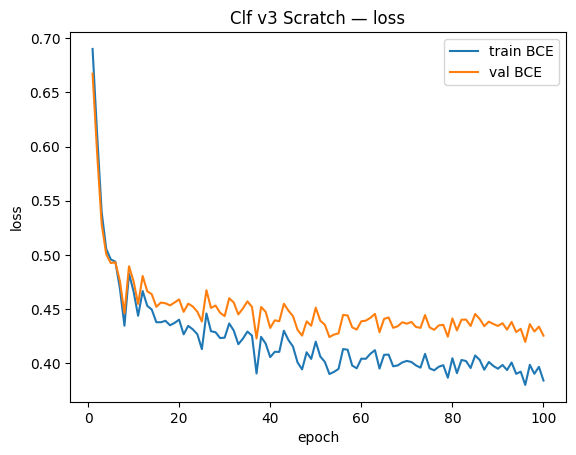

In [4]:
EPOCHS, BATCH, LR0 = 100, 64, 1e-3
EPS = 1e-12
history = {"epoch": [], "train_loss": [], "val_loss": [], "val_acc": [], "val_f1": [], "lr": []}
rng = np.random.default_rng(SEED)

def bce_plain(proba, y):
    p = np.clip(proba, EPS, 1 - EPS)
    return float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())

def eval_full(m):
    tr = bce_plain(m.predict_proba(train_ds.X).reshape(-1, 1), train_ds.y)
    pv = m.predict_proba(test_ds.X)
    pred = (pv >= 0.5).astype(int)
    vl = bce_plain(pv.reshape(-1, 1), test_ds.y)
    return tr, vl, accuracy_score(y_test, pred), f1_score(y_test, pred)

for epoch in range(1, EPOCHS + 1):
    lr = 0.5 * LR0 * (1 + np.cos(np.pi * (epoch - 1) / EPOCHS))
    for xb, yb in batch_generator(train_ds, BATCH, True, rng):
        B = len(xb)
        c = model.forward(xb, train=True)
        prob = sigmoid(c["out"])
        dlogit = (prob + prob * yb * (POS_W - 1) - POS_W * yb) / B
        model.adam_step(model.backward(dlogit, c, xb), lr)
    tr, vl, va, vf = eval_full(model)
    history["epoch"].append(epoch)
    history["train_loss"].append(tr)
    history["val_loss"].append(vl)
    history["val_acc"].append(va)
    history["val_f1"].append(vf)
    history["lr"].append(lr)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:03d} | train {tr:.4f} | val {vl:.4f} | acc {va:.4f} | F1 {vf:.4f} | lr {lr:.2e}")

np.savez("weights_v3/classification_scratch.npz",
         W1=model.W1, b1=model.b1, g1=model.g1, s1=model.s1, rm1=model.rm1, rv1=model.rv1,
         W2=model.W2, b2=model.b2, g2=model.g2, s2=model.s2, rm2=model.rm2, rv2=model.rv2,
         W3=model.W3, b3=model.b3, mean=scaler.mean_, scale=scaler.scale_,
         columns=np.array(FEATURE_COLS), train_median=np.array([train_median]))
pd.DataFrame(history).to_csv("weights_v3/classification_scratch_history.csv", index=False)
print("saved to weights_v3/")
plt.figure(); plt.plot(history["epoch"], history["train_loss"], label="train BCE")
plt.plot(history["epoch"], history["val_loss"], label="val BCE")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Clf v3 Scratch — loss"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights_v3/classification_scratch.npz`

In [5]:
z = np.load("weights_v3/classification_scratch.npz")
fresh = ScratchDeepMLP(in_dim=len(FEATURE_COLS), h=64, p=0.2, seed=0)
for n in ("W1", "b1", "g1", "s1", "rm1", "rv1", "W2", "b2", "g2", "s2", "rm2", "rv2", "W3", "b3"):
    setattr(fresh, n, z[n])
prob = fresh.predict_proba(test_ds.X)
pred = (prob >= 0.5).astype(int)
test_bce = bce_plain(prob.reshape(-1, 1), test_ds.y)
metrics = {
    "test_loss_BCE": round(float(test_bce), 4),
    "accuracy": round(float(accuracy_score(y_test, pred)), 4),
    "precision": round(float(precision_score(y_test, pred, zero_division=0)), 4),
    "recall": round(float(recall_score(y_test, pred, zero_division=0)), 4),
    "f1": round(float(f1_score(y_test, pred, zero_division=0)), 4),
    "roc_auc": round(float(roc_auc_score(y_test, prob)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights_v3/classification_scratch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
for i in range(5):
    print(f"  prob={prob[i]:.3f} pred={pred[i]} true={int(y_test[i])}")

{
  "test_loss_BCE": 0.4255,
  "accuracy": 0.7768,
  "precision": 0.3759,
  "recall": 0.7463,
  "f1": 0.5,
  "roc_auc": 0.8515,
  "n_test": 448,
  "seed": 42
}
  prob=0.023 pred=0 true=0
  prob=0.000 pred=0 true=0
  prob=0.019 pred=0 true=0
  prob=0.100 pred=0 true=0
  prob=0.018 pred=0 true=0


## 7. Parity check — scratch v3 vs PyTorch v3 oracle

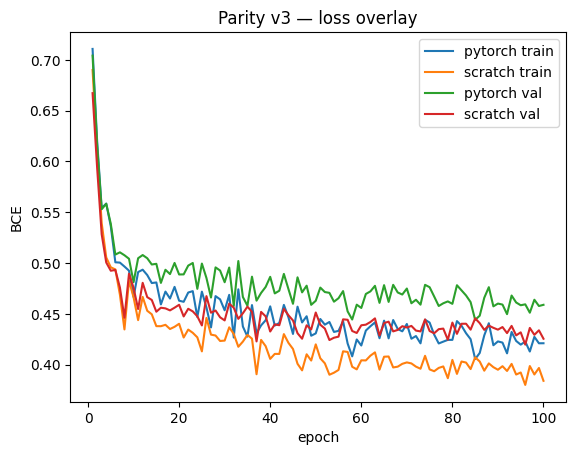

test_loss_BCE    0.4589   0.4255  absΔ=0.0334
accuracy         0.7388   0.7768  absΔ=0.0380
precision        0.3377   0.3759  absΔ=0.0382
recall           0.7761   0.7463  absΔ=0.0298
f1               0.4706      0.5  absΔ=0.0294
roc_auc          0.8466   0.8515  absΔ=0.0049

PARITY v3: PASS


In [6]:
import os as _os
assert _os.path.exists("weights_v3/classification_pytorch_history.csv"), "run classification_pytorch_v3.ipynb first"
ph = pd.read_csv("weights_v3/classification_pytorch_history.csv")
sh = pd.read_csv("weights_v3/classification_scratch_history.csv")
plt.figure(); plt.plot(ph["epoch"], ph["train_loss"], label="pytorch train")
plt.plot(sh["epoch"], sh["train_loss"], label="scratch train")
plt.plot(ph["epoch"], ph["val_loss"], label="pytorch val")
plt.plot(sh["epoch"], sh["val_loss"], label="scratch val")
plt.xlabel("epoch"); plt.ylabel("BCE"); plt.legend(); plt.title("Parity v3 — loss overlay"); plt.show()
pm = json.load(open("weights_v3/classification_pytorch_test_metrics.json"))
sm = json.load(open("weights_v3/classification_scratch_test_metrics.json"))
for k in ("test_loss_BCE", "accuracy", "precision", "recall", "f1", "roc_auc"):
    print(f"{k:<14}{pm[k]:>9}{sm[k]:>9}  absΔ={abs(sm[k]-pm[k]):.4f}")
loss_ok = abs(sm["test_loss_BCE"] - pm["test_loss_BCE"]) < 0.05
f1_ok = abs(sm["f1"] - pm["f1"]) < 0.05
print("\nPARITY v3:", "PASS" if (loss_ok and f1_ok) else "FAIL")